In [1]:
from ucimlrepo import fetch_ucirepo
import plotly.express as px
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import GridSearchCV
from utils import get_data, get_binary_data, get_binned_stratified_data, confusion, print_final_results


In [2]:
seed = 42
penalty = [None, 'l1', 'l2', 'elasticnet']
# no liblinear because it's not multiclass and the data set isn't even small
solvers = ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
cs = [0.001, 0.01, 1, 1.001, 1.01, 1.1, 2, 5, 100]

In [3]:
def test_everything(wine_X_tr, wine_y_tr, wine_X_val, wine_y_val):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)
        warnings.simplefilter("ignore", category=UserWarning)
        for solv in solvers:
            l1rat = 0
            for pen in penalty:
                match pen:
                    case 'elasticnet':
                        l1rat = 0.5
                    case 'l1':
                        l1rat = 1
                try:
                    max_c = 0
                    max_val_accuracy = 0
                    max_classifier = LogisticRegression(solver=solv, penalty=pen, max_iter = 1, random_state = seed)
                    for c in cs:
                        classifier = LogisticRegression(solver=solv, penalty=pen, max_iter = 100, C=c, l1_ratio=l1rat, random_state = seed);
                        classifier.fit(wine_X_tr, wine_y_tr);
                        if(100*accuracy_score(wine_y_val, classifier.predict(wine_X_val)) > max_val_accuracy):
                            max_val_accuracy = 100*accuracy_score(wine_y_val, classifier.predict(wine_X_val))
                            max_classifier = classifier 
                            max_c = c
                    print(f'Params: solver: {solv}, penalty: {pen}, C: {max_c}')
                    print(f'Training accuracy: {100*accuracy_score(wine_y_tr, max_classifier.predict(wine_X_tr)):.2f}%' )
                    print(f'Validation accuracy: {100*accuracy_score(wine_y_val, max_classifier.predict(wine_X_val)):.2f}%\n' )
                except ValueError:
                    continue

In [4]:
wine_X_tr, wine_X_val, wine_X_test, wine_y_tr, wine_y_val, wine_y_test = get_binned_stratified_data(seed) # pyright: ignore[reportGeneralTypeIssues]
test_everything(wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)

Params: solver: lbfgs, penalty: None, C: 0.001
Training accuracy: 64.25%
Validation accuracy: 58.11%

Params: solver: lbfgs, penalty: l2, C: 100
Training accuracy: 64.03%
Validation accuracy: 58.11%

Params: solver: newton-cg, penalty: None, C: 0.001
Training accuracy: 64.03%
Validation accuracy: 58.11%

Params: solver: newton-cg, penalty: l2, C: 100
Training accuracy: 64.03%
Validation accuracy: 58.11%

Params: solver: newton-cholesky, penalty: None, C: 0.001
Training accuracy: 63.80%
Validation accuracy: 58.11%

Params: solver: newton-cholesky, penalty: l2, C: 100
Training accuracy: 64.03%
Validation accuracy: 58.11%

Params: solver: sag, penalty: None, C: 0.001
Training accuracy: 64.48%
Validation accuracy: 57.43%

Params: solver: sag, penalty: l2, C: 5
Training accuracy: 64.03%
Validation accuracy: 57.43%

Params: solver: saga, penalty: None, C: 0.001
Training accuracy: 64.48%
Validation accuracy: 57.43%

Params: solver: saga, penalty: l1, C: 100
Training accuracy: 64.48%
Validatio

/Users/tanishasingh/Documents copy/UCI/UCI_Y2Quarter2/cs178Final/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Results:
--- Accuracy (train): 64.03%
--- Accuracy (test): 54.05%


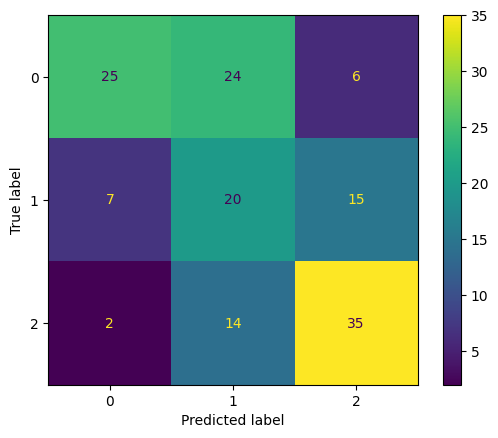

In [5]:
classifier =  LogisticRegression(solver='saga', penalty='l1', max_iter = 100, random_state = seed, C=1)
confusion(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)              

In [12]:
wine_X_tr, wine_X_val, wine_X_test, wine_y_tr, wine_y_val, wine_y_test = get_data(seed)
test_everything(wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)

#best appears to be saga l2 0.01

Params: solver: lbfgs, penalty: None, C: 0.001
Training accuracy: 54.99%
Validation accuracy: 55.08%

Params: solver: lbfgs, penalty: l2, C: 0.01
Training accuracy: 54.38%
Validation accuracy: 55.62%

Params: solver: newton-cg, penalty: None, C: 0.001
Training accuracy: 54.89%
Validation accuracy: 55.00%

Params: solver: newton-cg, penalty: l2, C: 0.01
Training accuracy: 54.40%
Validation accuracy: 55.62%

Params: solver: newton-cholesky, penalty: None, C: 0.001
Training accuracy: 54.89%
Validation accuracy: 55.00%

Params: solver: newton-cholesky, penalty: l2, C: 0.01
Training accuracy: 54.40%
Validation accuracy: 55.62%

Params: solver: sag, penalty: None, C: 0.001
Training accuracy: 54.81%
Validation accuracy: 55.00%

Params: solver: sag, penalty: l2, C: 0.01
Training accuracy: 54.40%
Validation accuracy: 55.62%

Params: solver: saga, penalty: None, C: 0.001
Training accuracy: 54.73%
Validation accuracy: 55.00%

Params: solver: saga, penalty: l1, C: 1
Training accuracy: 54.71%
Valid

Results:
--- Accuracy (train): 54.40%
--- Accuracy (test): 55.62%


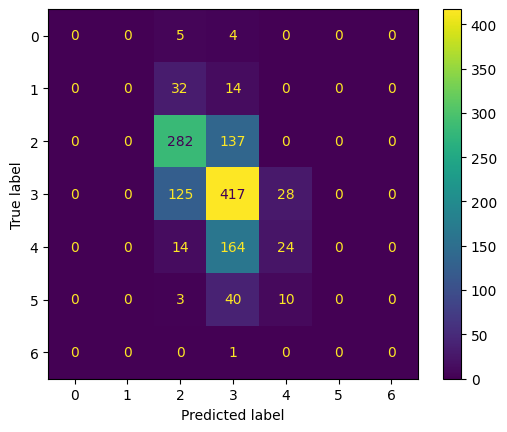

In [13]:
classifier =  LogisticRegression(solver='saga', penalty='l2', max_iter = 100, random_state = seed, C=0.01)
confusion(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)              

In [14]:
classifier =  LogisticRegression(solver='saga', penalty='l1', max_iter = 100, random_state = seed, C=1)
print_final_results(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val, wine_X_test, wine_y_test)

Results:
--- Accuracy (train): 54.71%
--- Accuracy (validation): 55.38%
--- Accuracy (test): 54.23%


/Users/tanishasingh/Documents copy/UCI/UCI_Y2Quarter2/cs178Final/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [15]:
wine_X_tr, wine_X_val, wine_X_test, wine_y_tr, wine_y_val, wine_y_test = get_binary_data(seed)
test_everything(wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)

Params: solver: lbfgs, penalty: None, C: 0.001
Training accuracy: 73.77%
Validation accuracy: 76.46%

Params: solver: lbfgs, penalty: l2, C: 1
Training accuracy: 73.80%
Validation accuracy: 76.46%

Params: solver: newton-cg, penalty: None, C: 0.001
Training accuracy: 73.75%
Validation accuracy: 76.38%

Params: solver: newton-cg, penalty: l2, C: 1
Training accuracy: 73.77%
Validation accuracy: 76.38%

Params: solver: newton-cholesky, penalty: None, C: 0.001
Training accuracy: 73.75%
Validation accuracy: 76.46%

Params: solver: newton-cholesky, penalty: l2, C: 1
Training accuracy: 73.77%
Validation accuracy: 76.38%

Params: solver: sag, penalty: None, C: 0.001
Training accuracy: 73.75%
Validation accuracy: 76.38%

Params: solver: sag, penalty: l2, C: 1
Training accuracy: 73.77%
Validation accuracy: 76.38%

Params: solver: saga, penalty: None, C: 0.001
Training accuracy: 73.75%
Validation accuracy: 76.38%

Params: solver: saga, penalty: l1, C: 1
Training accuracy: 73.77%
Validation accura

Results:
--- Accuracy (train): 73.77%
--- Accuracy (test): 76.46%


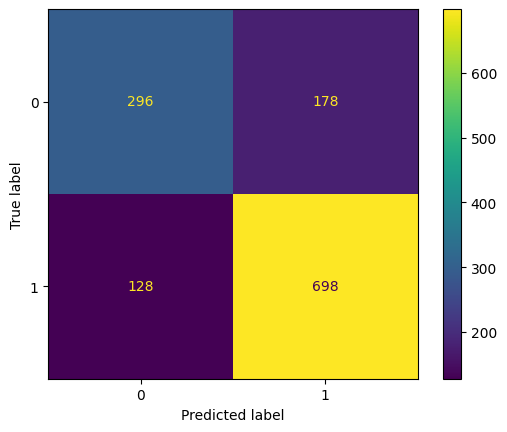

In [16]:
classifier =  LogisticRegression(solver='saga', penalty='l1', max_iter = 100, random_state = seed, C=1)
confusion(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)

In [17]:
classifier =  LogisticRegression(solver='saga', penalty='l1', max_iter = 100, random_state = seed, C=1)
print_final_results(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val, wine_X_test, wine_y_test)

Results:
--- Accuracy (train): 73.77%
--- Accuracy (validation): 76.46%
--- Accuracy (test): 72.62%


In [18]:
# # Create a figure with only one subplot
# figure, axes = plt.subplots(1, figsize=(6, 6))

# ### YOUR CODE STARTS HERE ###

# errors_tr = []
# errors_te = []

# k = [1, 2, 5, 10, 50, 100, 110]
# for i in range(len(k)):
#     knn_classifier = KNeighborsClassifier(n_neighbors=k[i])
#     knn_classifier.fit(peng_X_tr, peng_y_tr)
#     y_pred = knn_classifier.predict(peng_X_tr)
#     accuracy = accuracy_score(peng_y_tr, y_pred)
#     errors_tr.append(1-accuracy)
#     y_pred = knn_classifier.predict(peng_X_te)
#     accuracy = accuracy_score(peng_y_te, y_pred)
#     errors_te.append(1-accuracy)

# axes.semilogx(k, errors_tr, c='r', label = "training")
# axes.semilogx(k, errors_te, c = 'g', label = "testing")
# axes.set_xlabel('k')
# axes.set_ylabel('error')
# axes.legend()

# ### YOUR CODE ENDS HERE ###